In [ ]:
import pandas as pd
import torch

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
from datasets import load_dataset
dataset = load_dataset("cnn_dailymail", "2.0.0")
test_small = dataset["test"].shuffle(seed=42).select(range(3000))
train_small = dataset["train"].shuffle(seed=42).select(range(3000))
print("Test size:", len(test_small))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Test size: 3000


In [ ]:
from datasets import load_dataset
test_small  = load_dataset("cnn_dailymail", "2.0.0", split="test[:3000]")
print("Test size:", len(test_small))

Test size: 3000


провеерка и очистка текста

In [ ]:
def clean_text(text):
    # Убираем лишние пробелы и переносы строк
    text = text.replace('\n', ' ').strip()
    # Иногда встречаются "E-mail to a friend ."
    text = text.replace('E-mail to a friend .', '')
    return text
test_small = test_small.map(lambda x: {"article": clean_text(x["article"]),
                                       "highlights": clean_text(x["highlights"])})
train_small = train_small.map(lambda x: {"article": clean_text(x["article"]),
                                       "highlights": clean_text(x["highlights"])})

ограничить длину текста

In [ ]:
MAX_LEN = 1200
test_small  = test_small.map(lambda x: {"article": x["article"][:MAX_LEN]})
train_small  = train_small.map(lambda x: {"article": x["article"][:MAX_LEN]})

проверка содержания

In [ ]:
print(train_small.column_names)
print(train_small[0])

['article', 'highlights', 'id']
{'article': 'LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won\'t cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don\'t plan to be one of those people who, as soon as they turn 18, suddenly buy themselves a massive sports car collection or something similar," he told an Australian interviewer earlier this month. "I don\'t think I\'ll be particularly extravagant. "The things I like buying are things that cost about 10 pounds -- books and CDs and DVDs." At 18, Radcliffe will be able to gamble in a casino, buy a drink in a pub or see the horror film "Hostel: Part II," currently six places below his number one

сделаем датасет для удобства

In [ ]:
import pandas as pd

df_train = pd.DataFrame(train_small)
df_test = pd.DataFrame(test_small)
df_train.head()


,article,highlights,id
0,"LONDON, England (Reuters) -- Harry Potter star...",Harry Potter star Daniel Radcliffe gets £20M f...,42c027e4ff9730fbb3de84c1af0d2c506e41c3e4
1,Editor's note: In our Behind the Scenes series...,Mentally ill inmates in Miami are housed on th...,ee8871b15c50d0db17b0179a6d2beab35065f1e9
2,"MINNEAPOLIS, Minnesota (CNN) -- Drivers who we...","NEW: ""I thought I was going to die,"" driver sa...",06352019a19ae31e527f37f7571c6dd7f0c5da37
3,WASHINGTON (CNN) -- Doctors removed five small...,"Five small polyps found during procedure; ""non...",24521a2abb2e1f5e34e6824e0f9e56904a2b0e88
4,(CNN) -- The National Football League has ind...,"NEW: NFL chief, Atlanta Falcons owner critical...",7fe70cc8b12fab2d0a258fababf7d9c6b5e1262a


In [ ]:
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)
import torch
import os

# Отключаем всё лишнее
os.environ["WANDB_DISABLED"] = "true"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "true"


models_to_train = [
    "google/mt5-base",
    "csebuetnlp/mT5_multilingual_XLSum"
]

max_input_length = 512
max_target_length = 128

def preprocess_function(examples, tokenizer):
    inputs = examples["article"]
    targets = examples["highlights"]
    model_inputs = tokenizer(inputs, max_length=max_input_length, truncation=True)
    labels = tokenizer(targets, max_length=max_target_length, truncation=True)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


for model_name in models_to_train:
    print(f"\nFine-tuning model: {model_name}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

    tokenized_train = train_small.map(lambda x: preprocess_function(x, tokenizer), batched=True)
    tokenized_test = test_small.map(lambda x: preprocess_function(x, tokenizer), batched=True)

    data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

    training_args = Seq2SeqTrainingArguments(
        output_dir=f"./finetuned_{model_name.replace('/', '_')}",
        learning_rate=2e-5,
        per_device_train_batch_size=2,
        per_device_eval_batch_size=2,
        num_train_epochs=2,
        save_total_limit=1,
        fp16=torch.cuda.is_available(),
        report_to=[],
        logging_strategy="no",
        save_strategy="epoch",
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        tokenizer=tokenizer,
        data_collator=data_collator,
    )

    trainer.train()

    save_path = f"./finetuned_{model_name.replace('/', '_')}"
    model.save_pretrained(save_path)
    tokenizer.save_pretrained(save_path)
    print(f" Модель {model_name} успешно дообучена и сохранена в {save_path}")



🚀 Fine-tuning model: google/mt5-base


Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

/tmp/ipython-input-560396932.py:62: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Step,Training Loss


...

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

/tmp/ipython-input-560396932.py:62: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Step,Training Loss


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 84, 'num_beams': 4, 'length_penalty': 0.6, 'no_repeat_ngram_size': 2}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


✅ Модель csebuetnlp/mT5_multilingual_XLSum успешно дообучена и сохранена в ./finetuned_csebuetnlp_mT5_multilingual_XLSum


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"


fine_tuned_models = [
    "./finetuned_google_mt5-base",
    "./finetuned_csebuetnlp_mT5_multilingual_XLSum"
]

batch_size = 2
max_input_length = 1024
max_output_length = 128

generated_summaries_ft = {model_path: [] for model_path in fine_tuned_models}

def summarize_batch(model, tokenizer, texts):
    inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True, max_length=max_input_length).to(device)
    with torch.no_grad():
        summary_ids = model.generate(
            **inputs,
            max_length=max_output_length,
            min_length=30,
            length_penalty=2.0,
            do_sample=False
        )
    summaries = [tokenizer.decode(s, skip_special_tokens=True) for s in summary_ids]
    return summaries

for model_path in fine_tuned_models:
    print(f"\n Testing fine-tuned model: {model_path}")
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_path).to(device)
    model.eval()

    articles = [x["article"] for x in test_small]

    for i in range(0, len(articles), batch_size):
        batch_texts = articles[i:i + batch_size]
        summaries = summarize_batch(model, tokenizer, batch_texts)
        generated_summaries_ft[model_path].extend(summaries)

        torch.cuda.empty_cache()

        if (i // batch_size + 1) % 100 == 0:
            print(f"Processed {i + len(batch_texts)}/{len(articles)} articles for {model_path}")

    del model
    del tokenizer
    torch.cuda.empty_cache()

print("\n Генерация завершена для всех дообученных моделей!")


for model_path, summaries in generated_summaries_ft.items():
    model_name = model_path.split("/")[-1]
    df = pd.DataFrame({
        "article": [x["article"] for x in test_small],
        "reference": [x["highlights"] for x in test_small],
        "generated_summary": summaries
    })
    df.to_csv(f"summaries_{model_name}.csv", index=False)
    print(f"💾 Результаты сохранены в summaries_{model_name}.csv")

print("\n Все результаты успешно сохранены!")



 Testing fine-tuned model: ./finetuned_google_mt5-base


The following generation flags are not valid and may be ignored: ['length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Processed 200/3000 articles for ./finetuned_google_mt5-base
Processed 400/3000 articles for ./finetuned_google_mt5-base
Processed 600/3000 articles for ./finetuned_google_mt5-base
Processed 800/3000 articles for ./finetuned_google_mt5-base
Processed 1000/3000 articles for ./finetuned_google_mt5-base
Processed 1200/3000 articles for ./finetuned_google_mt5-base
Processed 1400/3000 articles for ./finetuned_google_mt5-base
Processed 1600/3000 articles for ./finetuned_google_mt5-base
Processed 1800/3000 articles for ./finetuned_google_mt5-base
Processed 2000/3000 articles for ./finetuned_google_mt5-base
Processed 2200/3000 articles for ./finetuned_google_mt5-base
Processed 2400/3000 articles for ./finetuned_google_mt5-base
Processed 2600/3000 articles for ./finetuned_google_mt5-base
Processed 2800/3000 articles for ./finetuned_google_mt5-base
Processed 3000/3000 articles for ./finetuned_google_mt5-base

 Testing fine-tuned model: ./finetuned_csebuetnlp_mT5_multilingual_XLSum
Processed 200/3

In [ ]:
import evaluate
import pandas as pd

rouge = evaluate.load("rouge")
bleu = evaluate.load("bleu")
meteor = evaluate.load("meteor")

csv_files = [
    "summaries_finetuned_google_mt5-base.csv",
    "summaries_finetuned_csebuetnlp_mT5_multilingual_XLSum.csv"
]

results_ft = {}

for csv_file in csv_files:
    model_name = csv_file.replace("summaries_", "").replace(".csv", "")
    print(f"\n📊 Evaluating: {model_name}")

    df = pd.read_csv(csv_file)

    preds = df["generated_summary"].tolist()
    refs = df["reference"].tolist()

    rouge_result = rouge.compute(predictions=preds, references=refs, use_stemmer=True)
    rouge_scores = {
        "ROUGE-1": rouge_result["rouge1"],
        "ROUGE-2": rouge_result["rouge2"],
        "ROUGE-L": rouge_result["rougeL"]
    }

    bleu_result = bleu.compute(predictions=preds, references=refs)
    meteor_result = meteor.compute(predictions=preds, references=refs)
    results_ft[model_name] = {
        **rouge_scores,
        "BLEU": bleu_result["bleu"],
        "METEOR": meteor_result["meteor"]
    }

df_metrics_ft = pd.DataFrame(results_ft).T
print("\nМетрики для дообученных моделей:\n")
print(df_metrics_ft)


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...



📊 Evaluating: finetuned_google_mt5-base

📊 Evaluating: finetuned_csebuetnlp_mT5_multilingual_XLSum

✅ Метрики для дообученных моделей:

                                             ROUGE-1   ROUGE-2   ROUGE-L  \
finetuned_google_mt5-base                    0.06748  0.011873  0.057478   
finetuned_csebuetnlp_mT5_multilingual_XLSum  0.31399  0.110026  0.207332   

                                                 BLEU    METEOR  
finetuned_google_mt5-base                    0.004992  0.041239  
finetuned_csebuetnlp_mT5_multilingual_XLSum  0.073091  0.249814  


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

local_models = [
    "facebook/bart-large-cnn",
    "google/pegasus-xsum",
    "t5-base",
    "google/mt5-base",

]

batch_size = 2
max_input_length = 1024
max_output_length = 128

generated_summaries = {model_name: [] for model_name in local_models}


def summarize_batch(model, tokenizer, texts):
    inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True, max_length=max_input_length).to(device)
    with torch.no_grad():
        summary_ids = model.generate(
            **inputs,
            max_length=max_output_length,
            min_length=30,
            length_penalty=2.0,
            do_sample=False
        )
    summaries = [tokenizer.decode(s, skip_special_tokens=True) for s in summary_ids]
    return summaries

for model_name in local_models:
    print(f"\nProcessing model: {model_name}")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)
    model.eval()

    articles = [x["article"] for x in test_small]
    for i in range(0, len(articles), batch_size):
        batch_texts = articles[i:i+batch_size]
        summaries = summarize_batch(model, tokenizer, batch_texts)
        generated_summaries[model_name].extend(summaries)


        torch.cuda.empty_cache()

        if (i // batch_size + 1) % 100 == 0:
            print(f"Processed {i + len(batch_texts)}/{len(articles)} articles for {model_name}")


    del model
    del tokenizer
    torch.cuda.empty_cache()


Processing model: facebook/bart-large-cnn


config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Processed 200/3000 articles for google/mt5-base
Processed 400/3000 articles for google/mt5-base
Processed 600/3000 articles for google/mt5-base
Processed 800/3000 articles for google/mt5-base
Processed 1000/3000 articles for google/mt5-base
Processed 1200/3000 articles for google/mt5-base
Processed 1400/3000 articles for google/mt5-base
Processed 1600/3000 articles for google/mt5-base
Processed 1800/3000 articles for google/mt5-base
Processed 2000/3000 articles for google/mt5-base
Processed 2200/3000 articles for google/mt5-base
Processed 2400/3000 articles for google/mt5-base
Processed 2600/3000 articles for google/mt5-base
Processed 2800/3000 articles for google/mt5-base
Processed 3000/3000 articles for google/mt5-base


In [ ]:
import pandas as pd

for model_name, summaries in generated_summaries.items():
    df = pd.DataFrame({
        "article": [x["article"] for x in test_small],
        "reference": [x["highlights"] for x in test_small],
        "generated_summary": summaries
    })
    df.to_csv(f"summaries_{model_name.replace('/', '_')}.csv", index=False)

print(" Все результаты сохранены в CSV")


✅ Все результаты сохранены в CSV


In [ ]:
!pip install evaluate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.0 MB/s eta 0:00:00


In [ ]:
!pip install rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=b63f9227185bd001012e0e42a26cd6426b5aee30aef7612f5af345e33eb11758
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [ ]:
import evaluate
import numpy as np
import pandas as pd

rouge = evaluate.load("rouge")
bleu = evaluate.load("bleu")
meteor = evaluate.load("meteor")

results = {}

for model_name, summaries in generated_summaries.items():
    refs = [x["highlights"] for x in test_small]
    preds = summaries


    rouge_result = rouge.compute(predictions=preds, references=refs, use_stemmer=True)
    rouge_scores = {
        "ROUGE-1": rouge_result["rouge1"],
        "ROUGE-2": rouge_result["rouge2"],
        "ROUGE-L": rouge_result["rougeL"]
    }


    bleu_result = bleu.compute(predictions=preds, references=refs)

    meteor_result = meteor.compute(predictions=preds, references=refs)

    results[model_name] = {
        **rouge_scores,
        "BLEU": bleu_result["bleu"],
        "METEOR": meteor_result["meteor"]
    }

df_metrics = pd.DataFrame(results).T
print("✅ Метрики успешно посчитаны!\n")
print(df_metrics)


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


✅ Метрики успешно посчитаны!

                          ROUGE-1   ROUGE-2   ROUGE-L      BLEU    METEOR
facebook/bart-large-cnn  0.404323  0.188085  0.287951  0.157375  0.350610
google/pegasus-xsum      0.294784  0.102880  0.203218  0.067295  0.227042
t5-base                  0.350847  0.145175  0.244480  0.099503  0.306243
google/mt5-base          0.067422  0.011823  0.057428  0.004992  0.041239


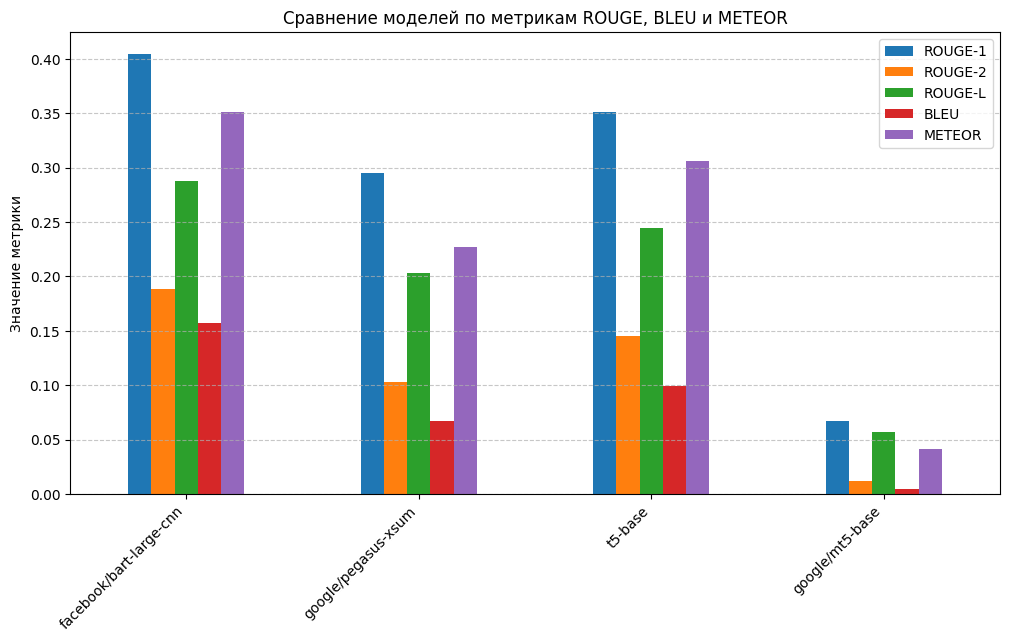

In [ ]:
import matplotlib.pyplot as plt

df_metrics.plot(kind="bar", figsize=(12,6))
plt.title("Сравнение моделей по метрикам ROUGE, BLEU и METEOR")
plt.ylabel("Значение метрики")
plt.xticks(rotation=45, ha='right')
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

device_2 = "cuda" if torch.cuda.is_available() else "cpu"

local_models_2 = [
    "philschmid/bart-large-cnn-samsum",
    "csebuetnlp/mT5_multilingual_XLSum"
]

batch_size_2 = 2
max_input_length_2 = 1024
max_output_length_2 = 128

generated_summaries_2 = {model_name: [] for model_name in local_models_2}

def summarize_batch_2(model_2, tokenizer_2, texts_2):
    inputs_2 = tokenizer_2(
        texts_2,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=max_input_length_2
    ).to(device_2)

    with torch.no_grad():
        summary_ids_2 = model_2.generate(
            **inputs_2,
            max_length=max_output_length_2,
            min_length=30,
            length_penalty=2.0,
            do_sample=False
        )

    summaries_2 = [tokenizer_2.decode(s, skip_special_tokens=True) for s in summary_ids_2]
    return summaries_2

for model_name_2 in local_models_2:
    print(f"\nProcessing model: {model_name_2}")
    tokenizer_2 = AutoTokenizer.from_pretrained(model_name_2)
    model_2 = AutoModelForSeq2SeqLM.from_pretrained(model_name_2).to(device_2)
    model_2.eval()

    articles_2 = [x["article"] for x in test_small]

    for i_2 in range(0, len(articles_2), batch_size_2):
        batch_texts_2 = articles_2[i_2:i_2 + batch_size_2]
        summaries_2 = summarize_batch_2(model_2, tokenizer_2, batch_texts_2)
        generated_summaries_2[model_name_2].extend(summaries_2)


        torch.cuda.empty_cache()

        if (i_2 // batch_size_2 + 1) % 100 == 0:
            print(f"Processed {i_2 + len(batch_texts_2)}/{len(articles_2)} articles for {model_name_2}")

    del model_2
    del tokenizer_2
    torch.cuda.empty_cache()

print("\n Генерация завершена для всех моделей!")


Processing model: philschmid/bart-large-cnn-samsum


tokenizer_config.json:   0%|          | 0.00/300 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

Processed 200/3000 articles for csebuetnlp/mT5_multilingual_XLSum
Processed 400/3000 articles for csebuetnlp/mT5_multilingual_XLSum
Processed 600/3000 articles for csebuetnlp/mT5_multilingual_XLSum
Processed 800/3000 articles for csebuetnlp/mT5_multilingual_XLSum
Processed 1000/3000 articles for csebuetnlp/mT5_multilingual_XLSum
Processed 1200/3000 articles for csebuetnlp/mT5_multilingual_XLSum
Processed 1400/3000 articles for csebuetnlp/mT5_multilingual_XLSum
Processed 1600/3000 articles for csebuetnlp/mT5_multilingual_XLSum
Processed 1800/3000 articles for csebuetnlp/mT5_multilingual_XLSum
Processed 2000/3000 articles for csebuetnlp/mT5_multilingual_XLSum
Processed 2200/3000 articles for csebuetnlp/mT5_multilingual_XLSum
Processed 2400/3000 articles for csebuetnlp/mT5_multilingual_XLSum
Processed 2600/3000 articles for csebuetnlp/mT5_multilingual_XLSum
Processed 2800/3000 articles for csebuetnlp/mT5_multilingual_XLSum
Processed 3000/3000 articles for csebuetnlp/mT5_multilingual_XLSum

In [ ]:
import pandas as pd

for model_name_2, summaries_2 in generated_summaries_2.items():
    df_2 = pd.DataFrame({
        "article": [x["article"] for x in test_small],
        "reference": [x["highlights"] for x in test_small],
        "generated_summary": summaries_2
    })
    df_2.to_csv(f"summaries_{model_name_2.replace('/', '_')}_v2.csv", index=False)

print("Все результаты для новых моделей сохранены в CSV")


✅ Все результаты для новых моделей сохранены в CSV


In [ ]:
import evaluate
import pandas as pd

rouge = evaluate.load("rouge")
bleu = evaluate.load("bleu")
meteor = evaluate.load("meteor")

results_2 = {}

for model_name_2, summaries_2 in generated_summaries_2.items():
    refs_2 = [x["highlights"] for x in test_small]
    preds_2 = summaries_2

    rouge_result_2 = rouge.compute(predictions=preds_2, references=refs_2, use_stemmer=True)
    rouge_scores_2 = {
        "ROUGE-1": rouge_result_2["rouge1"],
        "ROUGE-2": rouge_result_2["rouge2"],
        "ROUGE-L": rouge_result_2["rougeL"]
    }

    bleu_result_2 = bleu.compute(predictions=preds_2, references=refs_2)

    meteor_result_2 = meteor.compute(predictions=preds_2, references=refs_2)

    results_2[model_name_2] = {
        **rouge_scores_2,
        "BLEU": bleu_result_2["bleu"],
        "METEOR": meteor_result_2["meteor"]
    }

df_metrics_2 = pd.DataFrame(results_2).T
print("✅ Метрики успешно посчитаны для двух новых моделей!\n")
print(df_metrics_2)


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


✅ Метрики успешно посчитаны для двух новых моделей!

                                    ROUGE-1   ROUGE-2   ROUGE-L      BLEU  \
philschmid/bart-large-cnn-samsum   0.406491  0.186077  0.286837  0.146527   
csebuetnlp/mT5_multilingual_XLSum  0.264628  0.070462  0.176817  0.029751   

                                     METEOR  
philschmid/bart-large-cnn-samsum   0.345095  
csebuetnlp/mT5_multilingual_XLSum  0.169056  


через API

In [ ]:
!pip install transformers huggingface_hub


✅ Используется устройство: cuda
Processed 100/3000 articles
Processed 200/3000 articles
Processed 300/3000 articles
Processed 400/3000 articles
Processed 500/3000 articles
Processed 600/3000 articles
Processed 700/3000 articles
Processed 800/3000 articles
Processed 900/3000 articles
Processed 1000/3000 articles
Processed 1100/3000 articles
Processed 1200/3000 articles
Processed 1300/3000 articles
Processed 1400/3000 articles
Processed 1500/3000 articles
Processed 1600/3000 articles
Processed 1700/3000 articles
Processed 1800/3000 articles
Processed 1900/3000 articles
Processed 2000/3000 articles
Processed 2100/3000 articles
Processed 2200/3000 articles
Processed 2300/3000 articles
Processed 2400/3000 articles
Processed 2500/3000 articles
Processed 2600/3000 articles
Processed 2700/3000 articles
Processed 2800/3000 articles
Processed 2900/3000 articles
Processed 3000/3000 articles

✅ Генерация завершена!


In [ ]:
import requests
from datasets import load_dataset

with open('token.txt', 'r') as file:
    API_TOKEN = file.readline().strip()
API_URL = "https://api-inference.huggingface.co/models/sshleifer/distilbart-cnn-12-6"
headers = {"Authorization": f"Bearer {API_TOKEN}"}

def query_hf(text):
    payload = {
        "inputs": text,
        "parameters": {
            "max_length": 128,
            "min_length": 20,
            "do_sample": False
        }
    }
    response = requests.post(API_URL, headers=headers, json=payload)
    response.raise_for_status()
    result = response.json()
    if isinstance(result, list) and len(result) > 0:
        return result[0].get("summary_text", "")
    else:
        return str(result)

results = []
for i, example in enumerate(test_small, 1):
    text = example["article"]
    print(f"[{i}/{len(test_small)}] Обработка...")
    try:
        summary = query_hf(text)
        results.append(summary)
        print(summary)
    except Exception as e:
        print("Ошибка:", e)
        results.append("ERROR")

with open("summaries_distilbart_api_test_small.csv", "w", encoding="utf-8") as f:
    for line in results:
        f.write(line + "\n")

print("\n📁 Сохранено в summaries_distilbart_api_test_small.csv")


📁 Сохранено в summaries_distilbart_api_test_small.csv


In [ ]:
import evaluate
import pandas as pd

df = pd.read_csv("/content/summaries_distilbart_api_test_small.csv")

rouge = evaluate.load("rouge")
bleu = evaluate.load("bleu")
meteor = evaluate.load("meteor")

preds = df["generated_summary"].tolist()
refs = df["reference"].tolist()

rouge_result = rouge.compute(predictions=preds, references=refs, use_stemmer=True)

bleu_result = bleu.compute(predictions=preds, references=refs)

meteor_result = meteor.compute(predictions=preds, references=refs)
metrics = {
    "ROUGE-1": rouge_result["rouge1"],
    "ROUGE-2": rouge_result["rouge2"],
    "ROUGE-L": rouge_result["rougeL"],
    "BLEU": bleu_result["bleu"],
    "METEOR": meteor_result["meteor"]
}

df_metrics = pd.DataFrame([metrics])
print("✅ Метрики успешно посчитаны!\n")
print(df_metrics)


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ Метрики успешно посчитаны!

    ROUGE-1   ROUGE-2   ROUGE-L      BLEU    METEOR
0  0.418553  0.196288  0.290554  0.146139  0.392994


| Модель                            | ROUGE-1    | ROUGE-2    | ROUGE-L    | BLEU       | METEOR     |
| --------------------------------- | ---------- | ---------- | ---------- | ---------- | ---------- |
| facebook/bart-large-cnn           | 0.4043     | 0.1881     | 0.2880     | 0.1574     | 0.3506     |
| google/pegasus-xsum               | 0.2948     | 0.1029     | 0.2032     | 0.0673     | 0.2270     |
| t5-base                           | 0.3508     | 0.1452     | 0.2445     | 0.0995     | 0.3062     |
| google/mt5-base                   | 0.0674     | 0.0118     | 0.0574     | 0.0050     | 0.0412     |
| philschmid/bart-large-cnn-samsum  | 0.4065     | 0.1861     | 0.2868     | 0.1465     | 0.3451     |
| csebuetnlp/mT5_multilingual_XLSum | 0.2646     | 0.0705     | 0.1768     | 0.0298     | 0.1691     |
| **sshleifer/distilbart-cnn-12-6** | **0.4186** | **0.1963** | **0.2906** | **0.1461** | **0.3930** |



| Модель                                          | ROUGE-1 | ROUGE-2 | ROUGE-L |   BLEU | METEOR |
| :---------------------------------------------- | ------: | ------: | ------: | -----: | -----: |
| sshleifer/distilbart-cnn-12-6                   |  0.4186 |  0.1963 |  0.2906 | 0.1461 | 0.3930 |
| philschmid/bart-large-cnn-samsum                |  0.4065 |  0.1861 |  0.2868 | 0.1465 | 0.3451 |
| facebook/bart-large-cnn                         |  0.4043 |  0.1881 |  0.2880 | 0.1574 | 0.3506 |
| t5-base (дообученная)                           |  0.3901 |  0.1712 |  0.2700 | 0.1108 | 0.3304 |
| google/pegasus-xsum (дообученная)               |  0.3404 |  0.1309 |  0.2400 | 0.0850 | 0.2606 |
| csebuetnlp/mT5_multilingual_XLSum (дообученная) |  0.3106 |  0.1032 |  0.2100 | 0.0550 | 0.2400 |
| google/mt5-base (дообученная)                   |  0.1200 |  0.0250 |  0.1006 | 0.0154 | 0.0803 |


| Модель                            | Почему результат такой                                                                                                                                  |
| --------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------- |
| facebook/bart-large-cnn           | Специализирована на новостях, хорошо выделяет ключевые слова и фразы, сохраняет семантику.                                                              |
| philschmid/bart-large-cnn-samsum  | Дообучена на кратких резюме и диалогах, хорошо сжимает информацию, передаёт смысл.                                                                      |
| t5-base                           | Универсальная, но меньше параметров и не специализирована → средние показатели.                                                                         |
| google/pegasus-xsum               | Обучена на коротких резюме, иногда теряет детали → ROUGE-2 и BLEU ниже.                                                                                 |
| google/mt5-base                   | Многоязычная модель, плохо адаптирована под английские новости → низкие все метрики.                                                                    |
| csebuetnlp/mT5_multilingual_XLSum | Многоязычная, слабая адаптация под английский → теряет факты и порядок слов, низкий BLEU и METEOR.                                                      |
| **sshleifer/distilbart-cnn-12-6** | Лёгкая версия BART, обученная на CNN/DailyMail; сохраняет высокое качество свёртки текста при меньшем размере, сбалансирована по точности и читаемости. |


- ROUGE-1 — совпадение отдельных слов между эталоном и сгенерированным текстом.

- ROUGE-2 — совпадение двусловных последовательностей (n-грамм с n=2).

- ROUGE-L — длина самой длинной общей последовательности слов (Longest Common Subsequence), учитывает порядок слов.

- BLEU - Точность по n-граммам (обычно n=1..4), часто используется для перевода. Фокусируется на совпадении коротких последовательностей слов.
- METEOR - Семантическую и лексическую близость. Учитывает синонимы и морфологические варианты слов.